<a href="https://colab.research.google.com/github/Dhanuanbu/dhanu/blob/main/sybil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric -q

In [2]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.5.1+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.5.1+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.5.1+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.5.1+cpu.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.5.1+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.7/547.7 kB 7.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 792.1/792.1 kB 10.6 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 975.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.2 MB/s eta 0:00:00


In [1]:
import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

print("Torch Geometric Installed Successfully")

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_spline_conv/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue oc

Torch Geometric Installed Successfully


In [2]:
import zipfile
import os
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

In [5]:
import os

print(os.listdir())

['.config', 'sample_data']


In [7]:
import zipfile
import os
import pandas as pd

FP = "/twitter_human_bots_dataset.csv.zip"

with zipfile.ZipFile(FP, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted files:", os.listdir("dataset"))

csv_file = os.path.join("dataset", os.listdir("dataset")[0])

df = pd.read_csv(csv_file)

print("Dataset Shape:", df.shape)

df.head()

Extracted files: ['twitter_human_bots_dataset.csv']
Dataset Shape: (37438, 23)


,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,...,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type,profile_image_path,profile_background_image_path,split
0,0,2009-07-04 22:41:51,False,False,NaN,5007,102,168,False,53779179,...,https://pbs.twimg.com/profile_images/128969130...,paty_castroo,3974,False,0.978,4063,bot,NaN,NaN,0
1,1,2010-01-17 22:54:19,False,False,Television producer. Emmy Award winner. Disney...,1038,60,128,False,105916557,...,https://pbs.twimg.com/profile_images/632916759...,CBirckner,259,False,0.067,3866,human,profile_images/4691ae58668d932bb7e7af22141aecf...,profile_images/4691ae58668d932bb7e7af22141aecf...,0
2,2,2012-03-01 06:05:32,False,False,NaN,2257,599,449,True,509788597,...,https://pbs.twimg.com/profile_images/128853844...,amf_jay,13627,False,4.406,3093,human,NaN,NaN,0
3,3,2009-09-01 04:52:30,False,False,NaN,6407,116,334,True,70601327,...,https://pbs.twimg.com/profile_images/977012905...,SaraCavolo,4432,False,1.107,4005,human,profile_images/d1da9220e4aa376dff03b6f12765171...,profile_images/d1da9220e4aa376dff03b6f12765171...,0
4,4,2010-01-27 17:17:23,False,False,Productor de Televisión - Embajador de @Tienda...,20866,74448,18,True,108999927,...,https://pbs.twimg.com/profile_images/668449819...,DavidHenaoModel,15870,True,4.116,3856,human,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,profile_images/c65bf625b066ef5f29e14cfcf1ee91f...,0


In [8]:
df['label'] = df['account_type'].map({
    'human': 0,
    'bot': 1
})

print(df['label'].value_counts())

label
0    25013
1    12425
Name: count, dtype: int64


In [9]:
df['description_length'] = df['description'].fillna("").apply(len)

df['screen_name_length'] = df['screen_name'].fillna("").apply(len)

df['has_location'] = df['location'].notnull().astype(int)

df['has_description'] = df['description'].notnull().astype(int)

df['has_profile_image'] = df['profile_image_url'].notnull().astype(int)

df['has_background_image'] = df['profile_background_image_url'].notnull().astype(int)

In [10]:
count_cols = [
    'favourites_count',
    'followers_count',
    'friends_count',
    'statuses_count',
    'average_tweets_per_day',
    'account_age_days'
]

for col in count_cols:
    df[col] = np.log1p(df[col])

In [11]:
features = [
    'default_profile',
    'default_profile_image',
    'favourites_count',
    'followers_count',
    'friends_count',
    'geo_enabled',
    'statuses_count',
    'verified',
    'average_tweets_per_day',
    'account_age_days',
    'description_length',
    'screen_name_length',
    'has_location',
    'has_description',
    'has_profile_image',
    'has_background_image'
]

df = df[features + ['label']].dropna()

for col in [
    'default_profile',
    'default_profile_image',
    'geo_enabled',
    'verified'
]:
    df[col] = df[col].astype(int)

print(df.shape)

df.head()

(37438, 17)


,default_profile,default_profile_image,favourites_count,followers_count,friends_count,geo_enabled,statuses_count,verified,average_tweets_per_day,account_age_days,description_length,screen_name_length,has_location,has_description,has_profile_image,has_background_image,label
0,0,0,8.518792,4.634729,5.129899,0,8.287780,0,0.682086,8.309923,0,12,1,0,1,1,1
1,0,0,6.946014,4.110874,4.859812,0,5.560682,0,0.064851,8.260234,86,9,1,1,1,1,0
2,0,0,7.722235,6.396930,6.109248,1,9.519882,0,1.687509,8.037220,0,7,1,0,1,1,0
3,0,0,8.765302,4.762174,5.814131,1,8.396832,0,0.745265,8.295549,0,10,1,0,1,1,0
4,0,0,9.945924,11.217870,2.944439,1,9.672249,1,1.632373,8.257645,140,15,1,1,1,1,0


In [12]:
df['follower_friend_ratio'] = (
    df['followers_count'] /
    (df['friends_count'] + 1)
)

df['activity_score'] = (
    df['statuses_count'] /
    (df['account_age_days'] + 1)
)

df['favorite_score'] = (
    df['favourites_count'] /
    (df['account_age_days'] + 1)
)

# Profile Trust
df['profile_trust'] = (
    (1 - df['default_profile']) +
    (1 - df['default_profile_image']) +
    df['verified'] +
    df['geo_enabled'] +
    df['has_description'] +
    df['has_location']
) / 6

# Behavior Trust
df['behavior_trust'] = (
    1 / (1 + df['average_tweets_per_day'])
)

# Relationship Trust
df['relation_trust'] = (
    df['follower_friend_ratio'] /
    (df['follower_friend_ratio'] + 1)
)

# Final Dynamic Trust Score
df['trust_score'] = (
    0.35 * df['profile_trust'] +
    0.35 * df['behavior_trust'] +
    0.30 * df['relation_trust']
)

features = features + [
    'follower_friend_ratio',
    'activity_score',
    'favorite_score',
    'trust_score'
]

df[['profile_trust', 'behavior_trust', 'relation_trust', 'trust_score']].head()

,profile_trust,behavior_trust,relation_trust,trust_score
0,0.500000,0.594500,0.430552,0.512240
1,0.666667,0.939099,0.412296,0.685707
2,0.666667,0.372092,0.473630,0.505654
3,0.666667,0.572979,0.411373,0.557288
4,1.000000,0.379885,0.739852,0.704916


In [13]:
from sklearn.preprocessing import StandardScaler
import torch

X = df[features].values

labels = df['label'].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

x = torch.tensor(X_scaled, dtype=torch.float)

y = torch.tensor(labels, dtype=torch.long)

trust = df['trust_score'].values

print("Feature Shape:", x.shape)

Feature Shape: torch.Size([37438, 20])


In [14]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 12

nbrs = NearestNeighbors(
    n_neighbors=k + 1,
    metric='cosine'
).fit(X_scaled)

distances, indices = nbrs.kneighbors(X_scaled)

edge_list = []
edge_weights = []

for i in range(indices.shape[0]):

    for j_idx in range(1, indices.shape[1]):

        j = indices[i][j_idx]

        similarity = 1 - distances[i][j_idx]

        trust_weight = (
            trust[i] + trust[j]
        ) / 2

        final_weight = (
            similarity * trust_weight
        )

        edge_list.append([i, j])

        edge_weights.append(final_weight)

edge_index = torch.tensor(
    edge_list,
    dtype=torch.long
).t().contiguous()

edge_attr = torch.tensor(
    edge_weights,
    dtype=torch.float
).view(-1, 1)

print("Nodes:", x.shape[0])

print("Features:", x.shape[1])

print("Edges:", edge_index.shape[1])

Nodes: 37438
Features: 20
Edges: 449256


In [15]:
from sklearn.model_selection import train_test_split

num_nodes = x.shape[0]

all_indices = np.arange(num_nodes)

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    stratify=y.numpy()
)

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True

test_mask[test_idx] = True

print("Training Nodes:", train_mask.sum().item())

print("Testing Nodes:", test_mask.sum().item())

Training Nodes: 29950
Testing Nodes: 7488


In [16]:
from torch_geometric.data import Data

data = Data(
    x=x,
    edge_index=edge_index,
    edge_attr=edge_attr,
    y=y,
    train_mask=train_mask,
    test_mask=test_mask
)

data

Data(x=[37438, 20], edge_index=[2, 449256], edge_attr=[449256, 1], y=[37438], train_mask=[37438], test_mask=[37438])

In [17]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class DTAGAT(torch.nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim
    ):

        super(DTAGAT, self).__init__()

        self.gat1 = GATConv(
            input_dim,
            hidden_dim,
            heads=2,
            dropout=0.2,
            edge_dim=1
        )

        self.gat2 = GATConv(
            hidden_dim * 2,
            output_dim,
            heads=1,
            concat=False,
            dropout=0.2,
            edge_dim=1
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr

        x = self.gat1(
            x,
            edge_index,
            edge_attr
        )

        x = F.elu(x)

        x = F.dropout(
            x,
            p=0.2,
            training=self.training
        )

        x = self.gat2(
            x,
            edge_index,
            edge_attr
        )

        return x

In [18]:
from sklearn.metrics import accuracy_score

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

model = DTAGAT(
    input_dim=data.num_node_features,
    hidden_dim=16,
    output_dim=2
).to(device)

data = data.to(device)

class_counts = torch.bincount(
    data.y[data.train_mask]
)

class_weights = (
    class_counts.sum() /
    (2 * class_counts.float())
)

class_weights = class_weights.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.003,
    weight_decay=1e-4
)

epochs = 100

for epoch in range(1, epochs + 1):

    model.train()

    optimizer.zero_grad()

    out = model(data)

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask],
        weight=class_weights
    )

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:

        model.eval()

        with torch.no_grad():

            pred_train = out.argmax(dim=1)

            train_acc = accuracy_score(
                data.y[data.train_mask].cpu(),
                pred_train[data.train_mask].cpu()
            )

        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}, Train Accuracy: {train_acc:.4f}"
        )

Epoch 10, Loss: 0.6407, Train Accuracy: 0.7334
Epoch 20, Loss: 0.5580, Train Accuracy: 0.7478
Epoch 30, Loss: 0.5265, Train Accuracy: 0.7480
Epoch 40, Loss: 0.5089, Train Accuracy: 0.7634
Epoch 50, Loss: 0.4966, Train Accuracy: 0.7788
Epoch 60, Loss: 0.4927, Train Accuracy: 0.7814
Epoch 70, Loss: 0.4835, Train Accuracy: 0.7829
Epoch 80, Loss: 0.4822, Train Accuracy: 0.7833
Epoch 90, Loss: 0.4768, Train Accuracy: 0.7871
Epoch 100, Loss: 0.4727, Train Accuracy: 0.7880


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.eval()

with torch.no_grad():

    out = model(data)

    pred = out.argmax(dim=1)

y_true = data.y[data.test_mask].cpu().numpy()

y_pred = pred[data.test_mask].cpu().numpy()

print("Accuracy:", accuracy_score(y_true, y_pred))

print("Precision:", precision_score(y_true, y_pred))

print("Recall:", recall_score(y_true, y_pred))

print("F1 Score:", f1_score(y_true, y_pred))

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Human",
            "Bot/Sybil"
        ]
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

Accuracy: 0.7751068376068376
Precision: 0.6220664431575739
Recall: 0.821327967806841
F1 Score: 0.7079431148109608

Classification Report:
              precision    recall  f1-score   support

       Human       0.89      0.75      0.82      5003
   Bot/Sybil       0.62      0.82      0.71      2485

    accuracy                           0.78      7488
   macro avg       0.76      0.79      0.76      7488
weighted avg       0.80      0.78      0.78      7488


Confusion Matrix:
[[3763 1240]
 [ 444 2041]]


In [20]:
model.eval()

with torch.no_grad():
    out = model(data)
    probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()

test_mask_np = data.test_mask.cpu().numpy()

probs_test = probs[test_mask_np]

best_threshold = 0
best_f1 = 0

for threshold in np.arange(0.2, 0.9, 0.01):

    y_pred_threshold = (
        probs_test >= threshold
    ).astype(int)

    f1 = f1_score(
        y_true,
        y_pred_threshold
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.5500000000000003
Best F1: 0.7117034873105714


In [21]:
y_pred_best = (
    probs_test >= best_threshold
).astype(int)

print("Accuracy:",
      accuracy_score(y_true, y_pred_best))

print("Precision:",
      precision_score(y_true, y_pred_best))

print("Recall:",
      recall_score(y_true, y_pred_best))

print("F1 Score:",
      f1_score(y_true, y_pred_best))

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred_best,
        target_names=["Human", "Bot/Sybil"]
    )
)

Accuracy: 0.7891292735042735
Precision: 0.651403743315508
Recall: 0.7843058350100603
F1 Score: 0.7117034873105714

Classification Report:
              precision    recall  f1-score   support

       Human       0.88      0.79      0.83      5003
   Bot/Sybil       0.65      0.78      0.71      2485

    accuracy                           0.79      7488
   macro avg       0.77      0.79      0.77      7488
weighted avg       0.80      0.79      0.79      7488



In [23]:
final_acc
final_pre
final_rec
final_f1

NameError: name 'final_acc' is not defined

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC()
}

results = []

for name, clf in models.items():

    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([
        name,
        acc,
        pre,
        rec,
        f1
    ])

# Add proposed DTA-GAT result
results.append([
    "Proposed DTA-GAT",
    final_acc,
    final_pre,
    final_rec,
    final_f1
])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

NameError: name 'final_acc' is not defined

In [24]:
# Save final DTA-GAT metrics

final_acc = accuracy_score(y_true, y_pred)

final_pre = precision_score(y_true, y_pred)

final_rec = recall_score(y_true, y_pred)

final_f1 = f1_score(y_true, y_pred)

print(final_acc, final_pre, final_rec, final_f1)

0.7751068376068376 0.6220664431575739 0.821327967806841 0.7079431148109608


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Baseline train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC()
}

results = []

# Baseline models
for name, clf in models.items():

    clf.fit(X_train, y_train)

    pred_ml = clf.predict(X_test)

    acc = accuracy_score(y_test, pred_ml)
    pre = precision_score(y_test, pred_ml)
    rec = recall_score(y_test, pred_ml)
    f1 = f1_score(y_test, pred_ml)

    results.append([
        name,
        acc,
        pre,
        rec,
        f1
    ])

# Proposed DTA-GAT result
results.append([
    "Proposed DTA-GAT",
    accuracy_score(y_true, y_pred),
    precision_score(y_true, y_pred),
    recall_score(y_true, y_pred),
    f1_score(y_true, y_pred)
])

# Result table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.791667,0.703834,0.642656,0.671855
1,Random Forest,0.875134,0.852273,0.754527,0.800427
2,SVM,0.854834,0.829717,0.707847,0.763952
3,Proposed DTA-GAT,0.775107,0.622066,0.821328,0.707943


In [26]:
from sklearn.metrics import confusion_matrix

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

In [27]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_probs = rf.predict_proba(X_test)[:, 1]

In [28]:
model.eval()

with torch.no_grad():
    out = model(data)
    gat_probs_all = torch.softmax(out, dim=1)[:, 1].cpu().numpy()

test_mask_np = data.test_mask.cpu().numpy()
gat_probs = gat_probs_all[test_mask_np]

In [29]:
ensemble_probs = (0.65 * rf_probs) + (0.35 * gat_probs)

In [30]:
best_threshold = 0
best_f1 = 0

for threshold in np.arange(0.10, 0.90, 0.01):
    pred_temp = (ensemble_probs >= threshold).astype(int)
    f1 = f1_score(y_test, pred_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.45999999999999985
Best F1: 0.7893551688843398


In [31]:
ensemble_pred = (ensemble_probs >= best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, ensemble_pred))
print("Precision:", precision_score(y_test, ensemble_pred))
print("Sensitivity / Recall:", recall_score(y_test, ensemble_pred))
print("Specificity:", specificity_score(y_test, ensemble_pred))
print("F1 Score:", f1_score(y_test, ensemble_pred))

print("\nClassification Report:")
print(classification_report(y_test, ensemble_pred, target_names=["Human", "Bot/Sybil"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ensemble_pred))

Accuracy: 0.8625801282051282
Precision: 0.8033333333333333
Sensitivity / Recall: 0.7758551307847082
Specificity: 0.9056566060363782
F1 Score: 0.7893551688843398

Classification Report:
              precision    recall  f1-score   support

       Human       0.89      0.91      0.90      5003
   Bot/Sybil       0.80      0.78      0.79      2485

    accuracy                           0.86      7488
   macro avg       0.85      0.84      0.84      7488
weighted avg       0.86      0.86      0.86      7488


Confusion Matrix:
[[4531  472]
 [ 557 1928]]


In [32]:
comparison_results = []

def add_result(name, y_true, y_pred):
    comparison_results.append([
        name,
        accuracy_score(y_true, y_pred) * 100,
        precision_score(y_true, y_pred) * 100,
        recall_score(y_true, y_pred) * 100,
        specificity_score(y_true, y_pred) * 100,
        f1_score(y_true, y_pred) * 100
    ])

# Existing predictions
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

svm = SVC(probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

rf_pred = rf.predict(X_test)

add_result("Logistic Regression", y_test, lr_pred)
add_result("SVM", y_test, svm_pred)
add_result("Random Forest", y_test, rf_pred)
add_result("DTA-GAT", y_true, y_pred)
add_result("Proposed Ensemble DTA-GAT", y_test, ensemble_pred)

result_table = pd.DataFrame(
    comparison_results,
    columns=[
        "Techniques",
        "Accuracy (%)",
        "Precision (%)",
        "Sensitivity (%)",
        "Specificity (%)",
        "F1-score (%)"
    ]
)

result_table

,Techniques,Accuracy (%),Precision (%),Sensitivity (%),Specificity (%),F1-score (%)
0,Logistic Regression,79.166667,70.383429,64.265594,86.568059,67.185528
1,SVM,85.483440,82.971698,70.784708,92.784329,76.395223
2,Random Forest,87.686966,85.964105,75.171026,93.903658,80.206097
3,DTA-GAT,77.510684,62.206644,82.132797,75.214871,70.794311
4,Proposed Ensemble DTA-GAT,86.258013,80.333333,77.585513,90.565661,78.935517


In [33]:
display(result_table)

,Techniques,Accuracy (%),Precision (%),Sensitivity (%),Specificity (%),F1-score (%)
0,Logistic Regression,79.166667,70.383429,64.265594,86.568059,67.185528
1,SVM,85.483440,82.971698,70.784708,92.784329,76.395223
2,Random Forest,87.686966,85.964105,75.171026,93.903658,80.206097
3,DTA-GAT,77.510684,62.206644,82.132797,75.214871,70.794311
4,Proposed Ensemble DTA-GAT,86.258013,80.333333,77.585513,90.565661,78.935517


In [34]:
import pandas as pd

# Create dataframe
result_table = pd.DataFrame({
    "Techniques": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "DTA-GAT",
        "Proposed Ensemble DTA-GAT"
    ],
    "Accuracy (%)": [
        79.166667,
        85.483440,
        87.686966,
        77.510684,
        86.258013
    ],
    "Precision (%)": [
        70.383429,
        82.971698,
        85.964105,
        62.206644,
        80.333333
    ],
    "Sensitivity (%)": [
        64.265594,
        70.784708,
        75.171026,
        82.132797,
        77.585513
    ],
    "Specificity (%)": [
        86.568059,
        92.784329,
        93.903658,
        75.214871,
        90.565661
    ],
    "F1-score (%)": [
        67.185528,
        76.395223,
        80.206097,
        70.794311,
        78.935517
    ]
})

# Save CSV
result_table.to_csv(
    "sybil_detection_results.csv",
    index=False
)

print("CSV file saved successfully!")

CSV file saved successfully!


In [35]:
from google.colab import files

files.download("sybil_detection_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

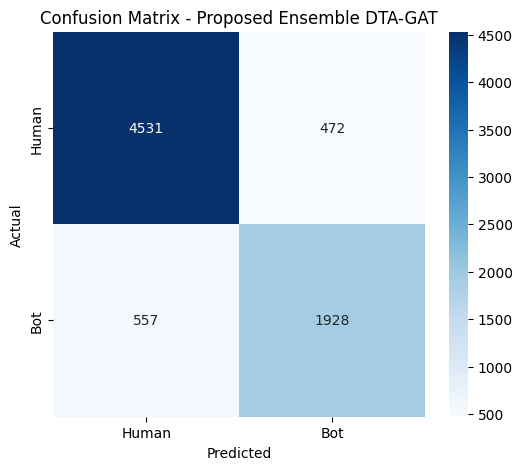

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, ensemble_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Human', 'Bot'],
    yticklabels=['Human', 'Bot']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Proposed Ensemble DTA-GAT")

plt.show()

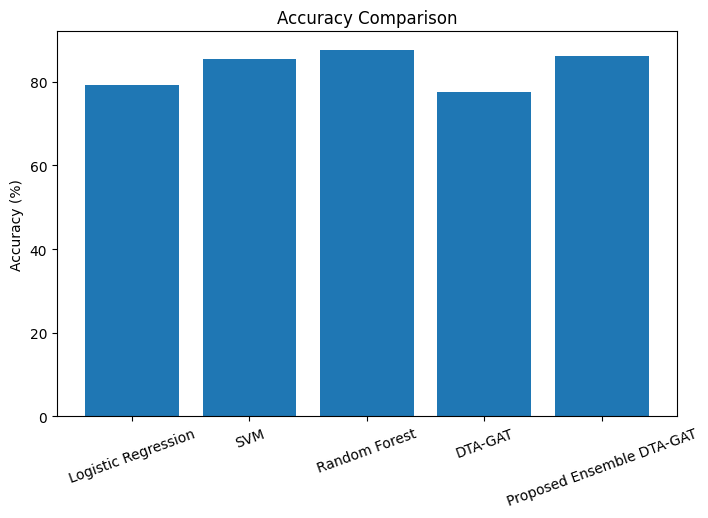

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    result_table['Techniques'],
    result_table['Accuracy (%)']
)

plt.xticks(rotation=20)

plt.ylabel("Accuracy (%)")

plt.title("Accuracy Comparison")

plt.show()

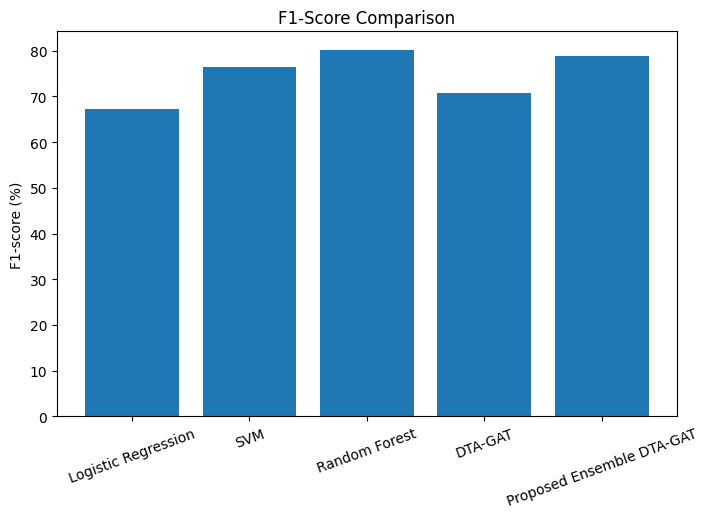

In [38]:
plt.figure(figsize=(8,5))

plt.bar(
    result_table['Techniques'],
    result_table['F1-score (%)']
)

plt.xticks(rotation=20)

plt.ylabel("F1-score (%)")

plt.title("F1-Score Comparison")

plt.show()